# Phase 1: Exploratory Data Analysis and Preprocessing


In [1]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
print(df.shape)
df.isnull().sum()
df['Class'].value_counts()

(284807, 31)


,count
Class,
0,284315
1,492


### Dataset Overview

- The dataset contains **284,807 rows** and **31 columns**.
- There are **no missing values** in the dataset.
- The target variable `Class` is highly imbalanced:
  - Normal transactions (Class = 0) are the majority.
  - Fraudulent transactions (Class = 1) form a very small fraction of the data.



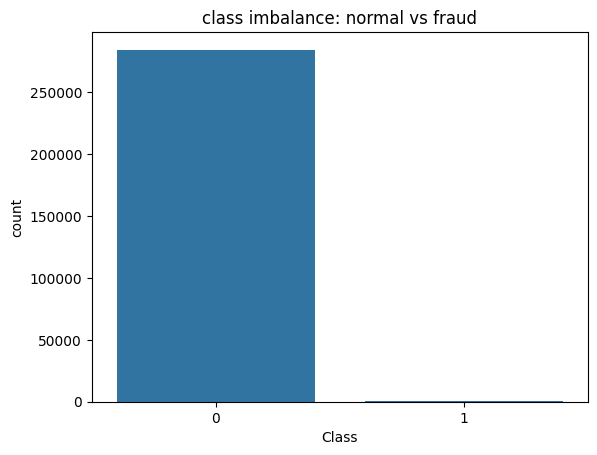

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class',data=df)
plt.title("class imbalance: normal vs fraud")
plt.show()

Fraud transactions are extremely rare (~0.17%), making accuracy an unreliable metric.

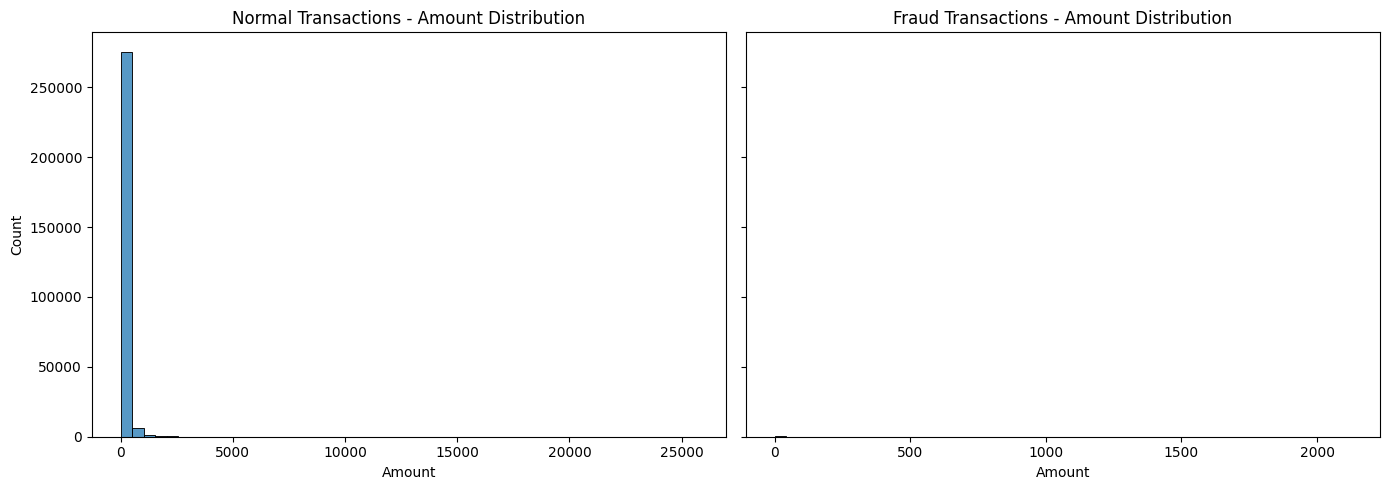

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Normal transactions
sns.histplot(
    df[df['Class'] == 0]['Amount'],
    bins=50,
    ax=axes[0]
)
axes[0].set_title("Normal Transactions - Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count")

# Fraud transactions
sns.histplot(
    df[df['Class'] == 1]['Amount'],
    bins=50,
    ax=axes[1]
)
axes[1].set_title("Fraud Transactions - Amount Distribution")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()


### Amount Distribution by Class (Subplots)

- Separate subplots are used due to extreme class imbalance.
- Both normal and fraudulent transactions are concentrated at low amounts.
- Fraudulent transactions overlap significantly with normal transactions.
- The presence of extreme outliers further motivates the use of RobustScaler.


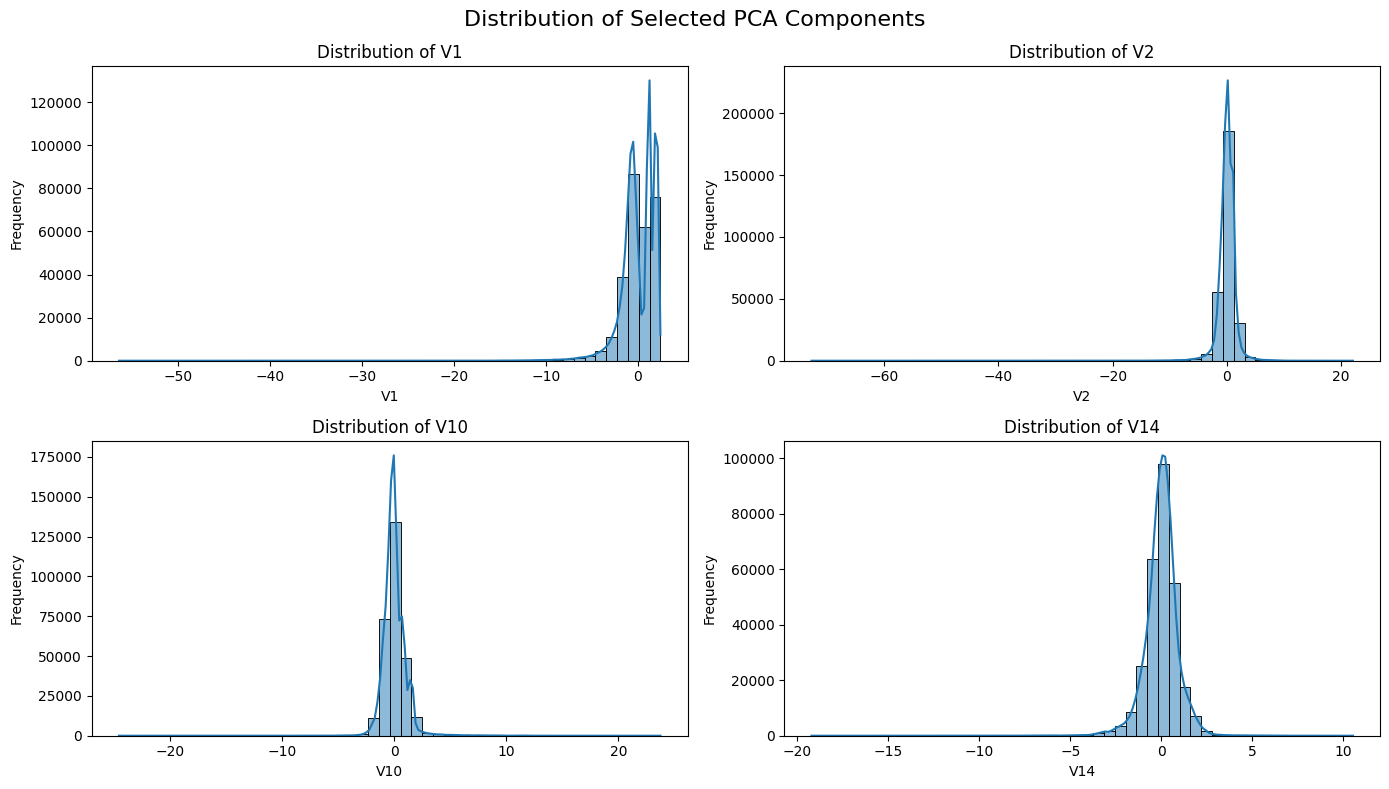

In [5]:

features = ['V1', 'V2', 'V10', 'V14']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle("Distribution of Selected PCA Components", fontsize=16)
plt.tight_layout()
plt.show()


### PCA Feature Distribution Analysis

- Selected PCA components show approximately symmetric distributions centered around zero.
- No single PCA feature provides a clear separation between normal and fraudulent transactions.
- The PCA features appear already scaled and standardized, confirming that additional scaling is unnecessary.


In [6]:
#robustscaler
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])


RobustScaler is used due to extreme outliers in transaction amounts.

#`EDA completed. Preprocessing strategy finalized.`

# Phase 2: Unsupervised Model Building
## Week 2: Isolation Forest Implementation


In [7]:
#week2
# Isolation Forest Model
import numpy as np
import pandas as pd

X = df.drop(columns=["Class"])
y = df["Class"]

X_normal = X[y == 0]

# Isolation Forest baseline model
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_normal)

y_pred_raw = iso_forest.predict(X)

# Convert to binary fraud labels
# -1 → 1 (fraud), 1 → 0 (normal)
y_pred = np.where(y_pred_raw == -1, 1, 0)

#Evaluation
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y, y_pred, digits=4))


Confusion Matrix:
 [[281471   2844]
 [   224    268]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9992    0.9900    0.9946    284315
           1     0.0861    0.5447    0.1487       492

    accuracy                         0.9892    284807
   macro avg     0.5427    0.7674    0.5717    284807
weighted avg     0.9976    0.9892    0.9931    284807



In [8]:
# Hyperparameter experiments
results = []

for n_estimators in [100, 200, 300]:
    for contamination in [0.005, 0.01, 0.02]:

        model = IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_normal)
        preds = model.predict(X)
        preds = np.where(preds == -1, 1, 0)

        report = classification_report(y, preds, output_dict=True)

        results.append({
            "n_estimators": n_estimators,
            "contamination": contamination,
            "precision_fraud": report["1"]["precision"],
            "recall_fraud": report["1"]["recall"],
            "f1_fraud": report["1"]["f1-score"]
        })

results_df = pd.DataFrame(results)
results_df


,n_estimators,contamination,precision_fraud,recall_fraud,f1_fraud
0,100,0.005,0.122222,0.402439,0.187500
1,100,0.010,0.086118,0.544715,0.148724
2,100,0.020,0.056882,0.697154,0.105182
3,200,0.005,0.122764,0.404472,0.188358
4,200,0.010,0.086118,0.544715,0.148724
5,200,0.020,0.056100,0.686992,0.103729
6,300,0.005,0.121680,0.400407,0.186641
7,300,0.010,0.084648,0.534553,0.146152
8,300,0.020,0.055316,0.676829,0.102273


#### Hyperparameter Experiments
We evaluate multiple configurations of Isolation Forest by varying the number of trees and the contamination parameter to identify an optimal balance between fraud recall and false positives.


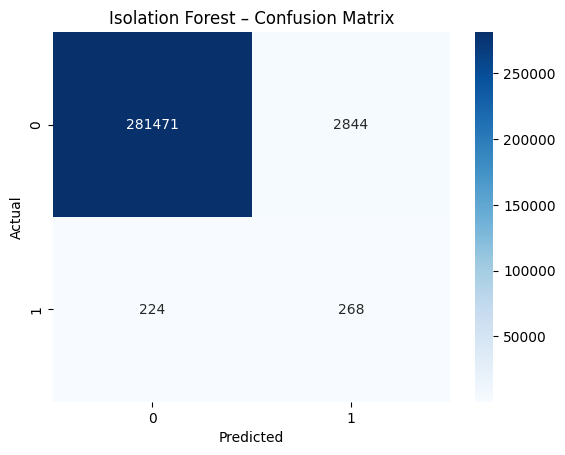

In [9]:
# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Isolation Forest – Confusion Matrix")
plt.show()


#### Model Evaluation
Performance is evaluated using confusion matrices and class-wise precision and recall, with particular emphasis on recall for the fraud class.
